<a href="https://www.kaggle.com/code/naveenkumartiwari/custom-functional-model-cnn?scriptVersionId=354394666" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.utils import plot_model

# SYNTAX OF FUNCTIONAL API

In [2]:
# Define input layer
# here 34, 34 is the shape of input
input_layer = Input(shape=(34,34))

In [3]:
# BUILD NETWORK BY CONNECTING LAYERS
hidden = Dense(64, activation='relu')(input_layer)
output = Dense(1)(hidden)

I0000 00:00:1790855256.172091      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790855256.175189      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# CREATE MODEL
model = Model(inputs=input_layer , outputs=output)

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 34, 34)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 34, 64)         │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

## SINGLE MULTI-OUTPUT MODEL EXAMPLE

In [6]:
x = Input(shape=(3,))

In [7]:
# shared layers
hidden1 = Dense(128, activation='relu')(x)
hidden2 = Dense(64, activation='relu')(hidden1)

In [8]:
# two output branches
output1 = Dense(1, activation='linear', name='age')(hidden2)
output2 = Dense(1, activation='sigmoid', name='place')(hidden2)

In [9]:
# create model with multiple outputs
model = Model(inputs=x, outputs = [output1, output2])


In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │         65 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ place (Dense)       │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# COMPILE WITH MULTIPLE LOSS
model.compile(
    optimizer='adam',
    loss={
        'age':'mse',
        'place':'binary_crossentropy'
    }
)

## MULTI-INPUT MODEL WITH CONCATENATION

In [12]:
# define two inputs
inputA = Input(shape=(32,))
inputB = Input(shape=(128,))

In [13]:
# Branch1
x1 = Dense(8, activation='relu')(inputA)
x2 = Dense(4, activation='relu')(x1)

In [14]:
# Branch2
y1= Dense(64, activation='relu')(inputB)
y2 = Dense(32, activation='relu')(y1)
y3 = Dense(4, activation='relu')(y2)

In [15]:
# Concatenate branches
from tensorflow.keras.layers import Concatenate
combined = Concatenate()([x2, y3])


In [16]:
# FINAL LAYERS
z = Dense(2, activation='relu')(combined)
z1 = Dense(1, activation='linear')(z)

In [17]:
# MODEL WITH MULTIPLE INPUTS
model = Model(inputs=[inputA, inputB], outputs=z1)

In [18]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │        264 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │         36 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 4)         │        132 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8)         │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 2)         │         18 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │          3 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,789 (42.14 KB)

 Trainable params: 10,789 (42.14 KB)

 Non-trainable params: 0 (0.00 B)

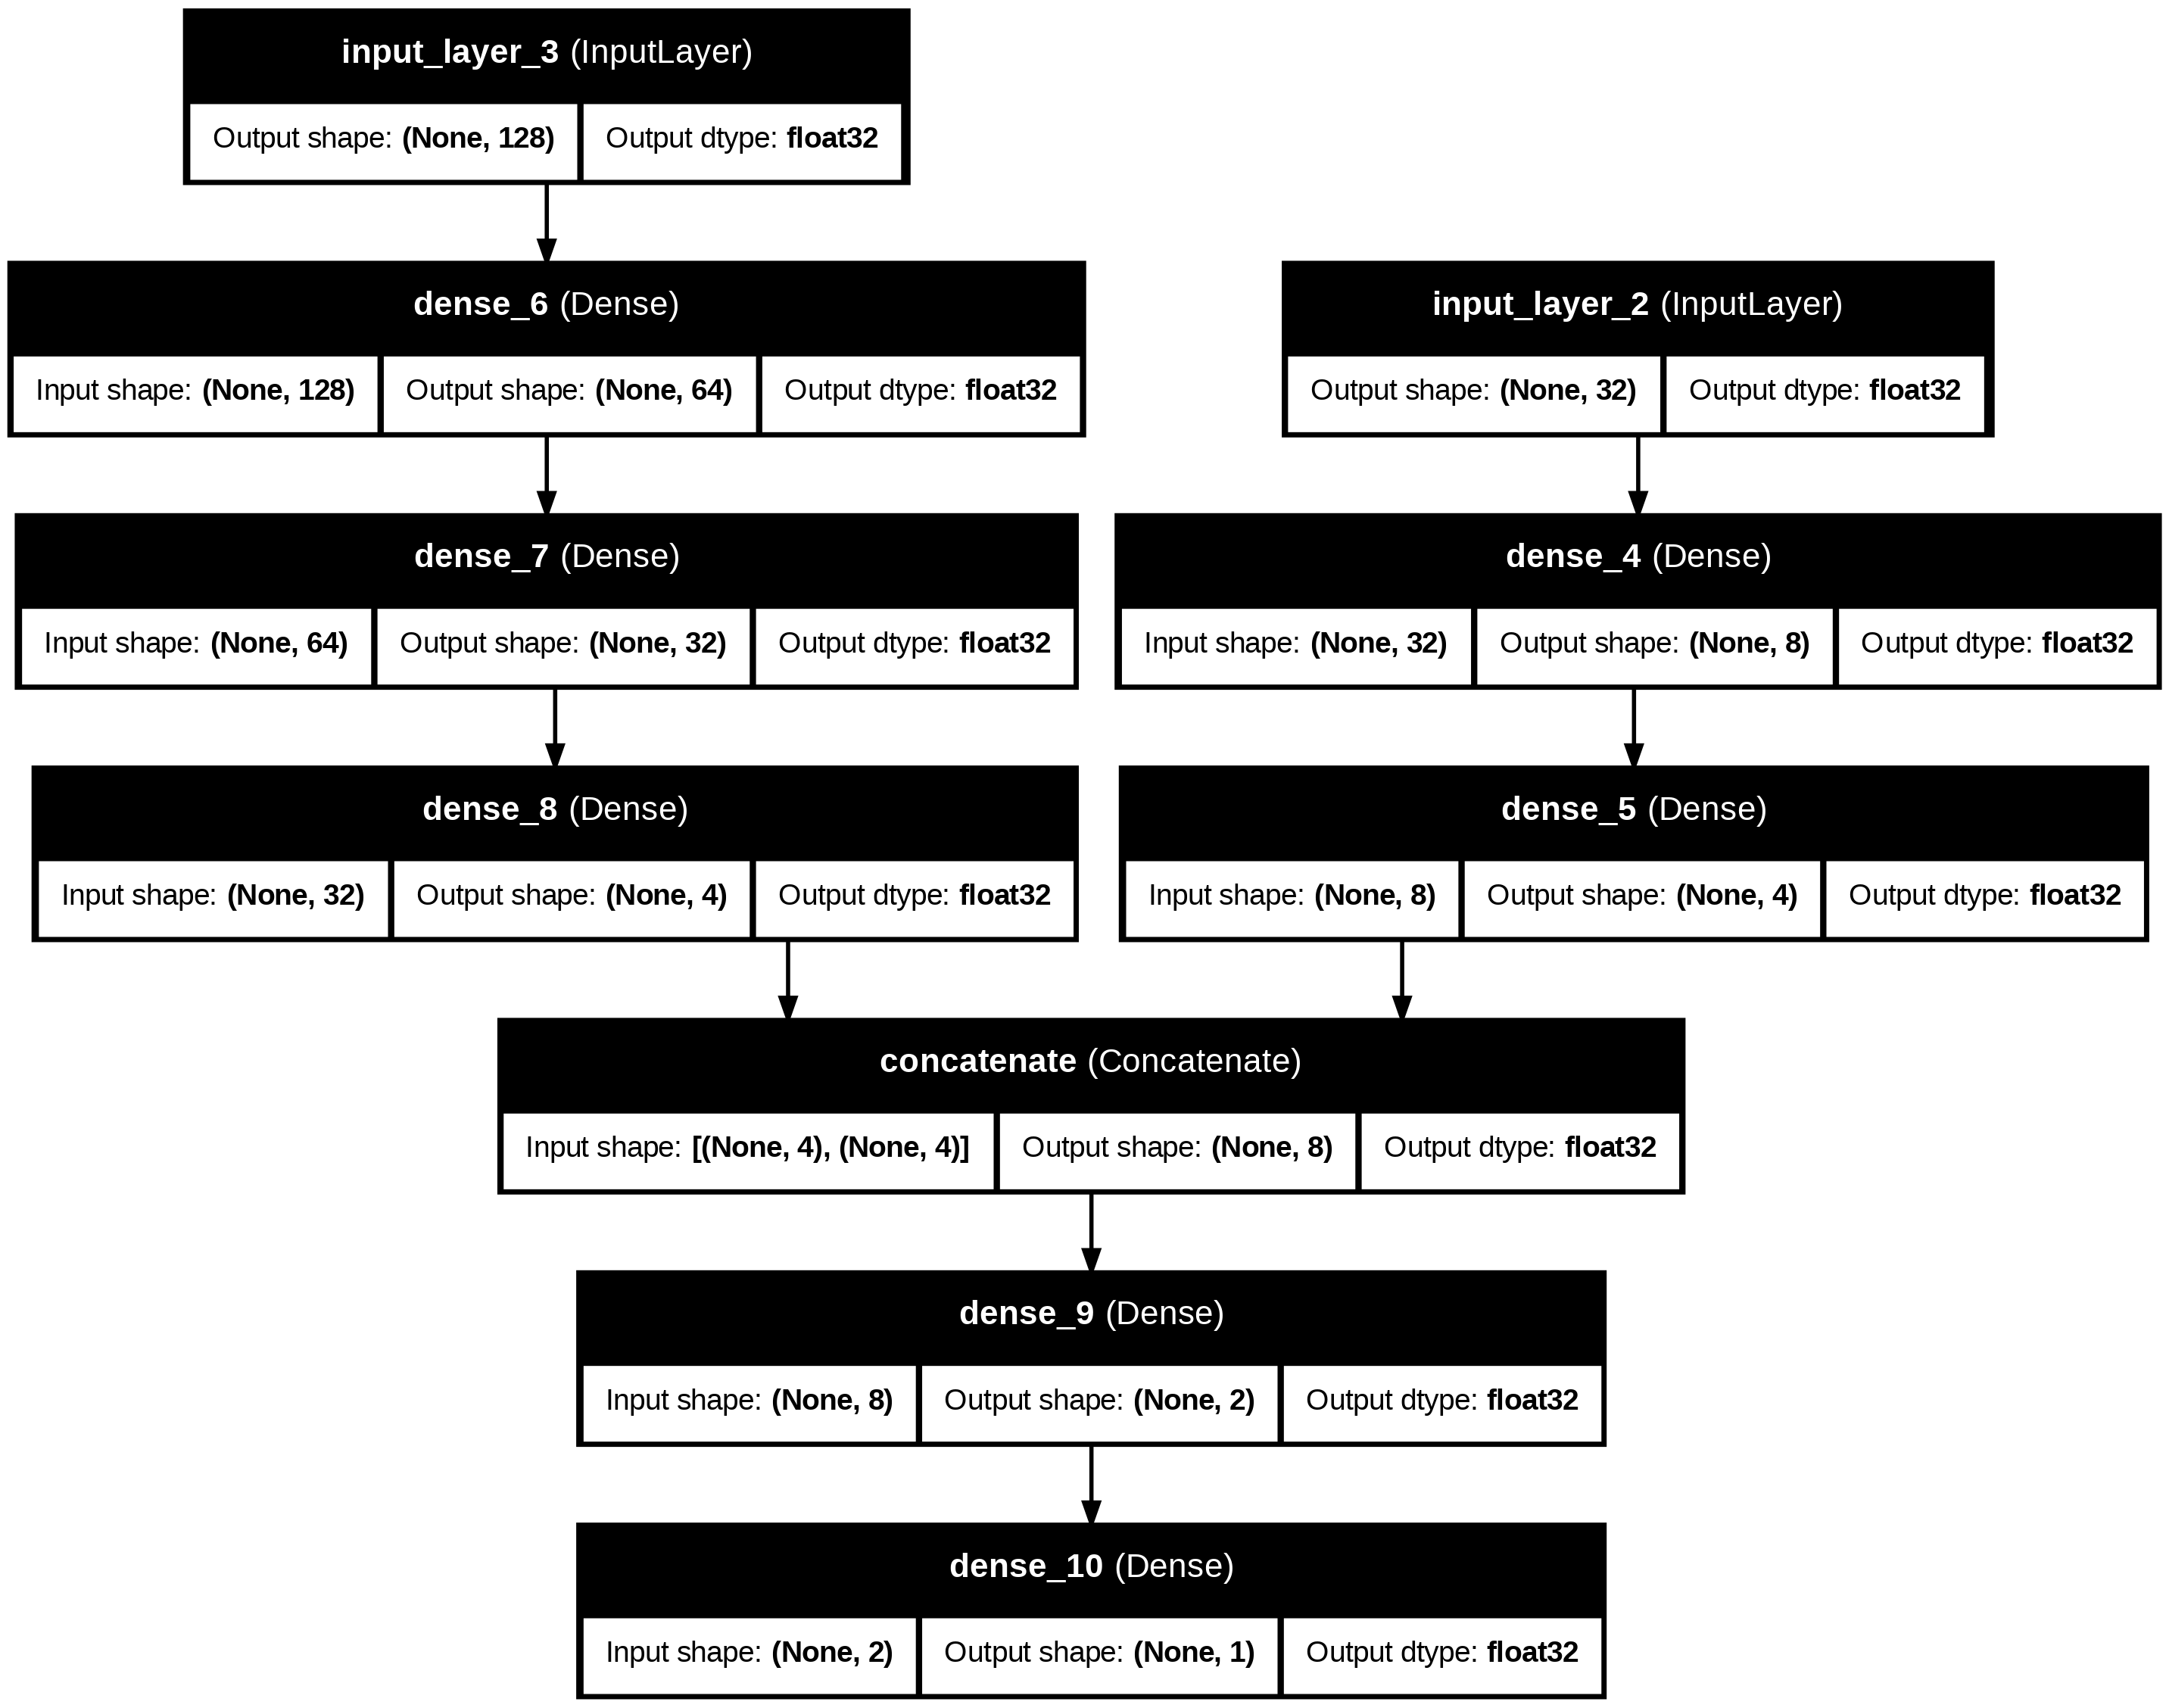

In [19]:
plot_model(model,show_shapes=True,
    show_dtype=True,
    show_layer_names=True,)

## UTK FACE CARD CLASSIFICATION - PRACTICAL IMPLEMENTATION

In [20]:
# Import required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model

In [21]:
# Check available datasets in Kaggle

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/abhikjha
/kaggle/input/datasets/abhikjha/utk-face-cropped
/kaggle/input/datasets/abhikjha/utk-face-cropped/utkcropped
/kaggle/input/datasets/abhikjha/utk-face-cropped/utkcropped/utkcropped


In [22]:
# Find the UTKFace image folder automatically

folder_path = None

for root, dirs, files in os.walk("/kaggle/input"):

    # Check whether this folder contains image files
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(image_files) > 100:
        folder_path = root
        break

print("Dataset folder:", folder_path)

Dataset folder: /kaggle/input/datasets/abhikjha/utk-face-cropped/utkcropped


In [23]:
# Create lists for age, gender and image path

age = []
gender = []
img_path = []

for file in os.listdir(folder_path):

    # Make sure it is an image
    if file.lower().endswith((".jpg", ".jpeg", ".png")):

        try:
            # Extract age from filename
            age.append(int(file.split("_")[0]))

            # Extract gender from filename
            gender.append(int(file.split("_")[1]))

            # Store image filename
            img_path.append(file)

        except:
            # Ignore files that don't follow the expected format
            pass


print("Total images:", len(img_path))

Total images: 23709


In [24]:
# Create a DataFrame

df = pd.DataFrame({
    "age": age,
    "gender": gender,
    "img": img_path
})

print(df.shape)

df.head()

(23709, 3)


,age,gender,img
0,26,0,26_0_2_20170104023102422.jpg.chip.jpg
1,22,1,22_1_1_20170112233644761.jpg.chip.jpg
2,21,1,21_1_3_20170105003215901.jpg.chip.jpg
3,28,0,28_0_0_20170117180555824.jpg.chip.jpg
4,17,1,17_1_4_20170103222931966.jpg.chip.jpg


In [25]:
# Check the gender distribution

print(df["gender"].value_counts())

gender
0    12391
1    11317
3        1
Name: count, dtype: int64


In [26]:
# Shuffle the complete dataset

df = df.sample(
    frac=1,
    random_state=0
).reset_index(drop=True)

# Use first 20,000 images for training
train_df = df.iloc[:20000]

# Use remaining images for testing/validation
test_df = df.iloc[20000:]

print("Training data:", train_df.shape)
print("Testing data :", test_df.shape)

Training data: (20000, 3)
Testing data : (3709, 3)


In [27]:
# Display some training records

train_df.head()

,age,gender,img
0,29,1,29_1_0_20170103181510040.jpg.chip.jpg
1,37,1,37_1_0_20170103182952754.jpg.chip.jpg
2,7,0,7_0_0_20170110215633251.jpg.chip.jpg
3,35,1,35_1_1_20170112215253641.jpg.chip.jpg
4,25,1,25_1_4_20170103235222492.jpg.chip.jpg


In [28]:
# Data augmentation for training images

train_datagen = ImageDataGenerator(

    # Normalize pixel values
    rescale=1./255,

    # Rotate images randomly
    rotation_range=30,

    # Shift images horizontally
    width_shift_range=0.2,

    # Shift images vertically
    height_shift_range=0.2,

    # Apply shear transformation
    shear_range=0.2,

    # Random zoom
    zoom_range=0.2,

    # Flip images horizontally
    horizontal_flip=True
)


# For testing/validation:
# Do NOT apply augmentation.
# Only normalize pixel values.

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [29]:
# Create training data generator

train_generator = train_datagen.flow_from_dataframe(

    train_df,

    directory=folder_path,

    x_col="img",

    # We have two target columns
    y_col=["age", "gender"],

    target_size=(200, 200),

    # We have two outputs
    class_mode="multi_output",

    batch_size=32,

    shuffle=True
)

Found 20000 validated image filenames.


In [30]:
# Create validation/test generator

test_generator = test_datagen.flow_from_dataframe(

    test_df,

    directory=folder_path,

    x_col="img",

    y_col=["age", "gender"],

    target_size=(200, 200),

    class_mode="multi_output",

    batch_size=32,

    # Keep order fixed during evaluation
    shuffle=False
)

Found 3709 validated image filenames.


In [31]:
# Load ResNet50 pretrained on ImageNet

resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(200, 200, 3)
)

resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [32]:
# Freeze ResNet50 layers
#
# The pretrained ResNet50 will act as a feature extractor.

resnet.trainable = False

In [33]:
# Get the output of the last ResNet50 layer

output = resnet.layers[-1].output

# Flatten the feature maps
flatten = Flatten()(output)

In [34]:
# -----------------------------------
# AGE BRANCH
# -----------------------------------

dense1 = Dense(
    512,
    activation="relu"
)(flatten)

dense3 = Dense(
    512,
    activation="relu"
)(dense1)


# Age output
# Linear activation because age is a continuous number

output1 = Dense(
    1,
    activation="linear",
    name="age"
)(dense3)


# -----------------------------------
# GENDER BRANCH
# -----------------------------------

dense2 = Dense(
    512,
    activation="relu"
)(flatten)

dense4 = Dense(
    512,
    activation="relu"
)(dense2)


# Gender output
# Sigmoid gives probability between 0 and 1

output2 = Dense(
    1,
    activation="sigmoid",
    name="gender"
)(dense4)

In [35]:
# Create a multi-output model

model = Model(
    inputs=resnet.input,
    outputs=[
        output1,
        output2
    ]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 126,875,522 (483.99 MB)

 Trainable params: 103,287,810 (394.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
# Compile the multi-output model

model.compile(

    optimizer="adam",

    # Loss for each output
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },

    # Metrics for each output
    metrics={
        "age": "mae",
        "gender": "accuracy"
    },

    # Give more importance to gender loss
    loss_weights={
        "age": 1,
        "gender": 99
    }
)

In [37]:
# Fix the multi-output generator for Keras

def multi_output_generator(generator):

    while True:

        images, targets = next(generator)

        # Convert list of targets into tuple
        yield images, (
            targets[0],
            targets[1]
        )


# Create fixed generators
train_generator_fixed = multi_output_generator(
    train_generator
)

test_generator_fixed = multi_output_generator(
    test_generator
)

In [38]:
# Train the model

history = model.fit(
    train_generator_fixed,

    steps_per_epoch=len(train_generator),

    epochs=10,

    validation_data=test_generator_fixed,

    validation_steps=len(test_generator)
)

Epoch 1/10
  2/625 ━━━━━━━━━━━━━━━━━━━━ 53s 86ms/step - age_loss: 32.7187 - age_mae: 32.7187 - gender_accuracy: 0.4219 - gender_loss: 9.5816 - loss: 981.2960   

I0000 00:00:1790855419.370907      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 333s 511ms/step - age_loss: 15.5055 - age_mae: 15.5055 - gender_accuracy: 0.5199 - gender_loss: 0.9014 - loss: 104.7449 - val_age_loss: 14.5182 - val_age_mae: 14.5182 - val_gender_accuracy: 0.5263 - val_gender_loss: 0.6918 - val_loss: 83.0070
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 363ms/step - age_loss: 15.0836 - age_mae: 15.0836 - gender_accuracy: 0.5224 - gender_loss: 0.6949 - loss: 83.8755 - val_age_loss: 14.5175 - val_age_mae: 14.5173 - val_gender_accuracy: 0.5263 - val_gender_loss: 0.6918 - val_loss: 83.0035
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 215s 344ms/step - age_loss: 14.9666 - age_mae: 14.9666 - gender_accuracy: 0.5217 - gender_loss: 0.6936 - loss: 83.6296 - val_age_loss: 14.5070 - val_age_mae: 14.5067 - val_gender_accuracy: 0.5263 - val_gender_loss: 0.6918 - val_loss: 82.9976
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 365ms/step - age_loss: 14.8176 - age_mae: 14.8176 - gender_accuracy: 0.5213 - gender_loss: 0.7005 - loss: 84.1663 - val

In [39]:
# ✅ Correct
results = model.evaluate(
    test_generator_fixed,
    steps=len(test_generator)
)

print("Evaluation completed.")
print(results)

116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - age_loss: 13.8968 - age_mae: 13.8965 - gender_accuracy: 0.5263 - gender_loss: 0.6918 - loss: 82.3835
Evaluation completed.
[82.38350677490234, 13.896846771240234, 0.6917811632156372, 13.896472930908203, 0.5262874364852905]


In [40]:
# Import image utilities

from tensorflow.keras.utils import load_img, img_to_array

In [41]:
# Function to predict age and gender

def predict_age_gender(image_path):

    # Load image
    img = load_img(
        image_path,
        target_size=(200, 200)
    )

    # Convert image to NumPy array
    img_array = img_to_array(img)

    # Normalize pixel values
    img_array = img_array / 255.0

    # Add batch dimension
    # (200,200,3) -> (1,200,200,3)
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Make prediction
    age_prediction, gender_prediction = model.predict(
        img_array,
        verbose=0
    )

    # Extract values
    predicted_age = age_prediction[0][0]

    predicted_gender_probability = gender_prediction[0][0]

    # Convert gender probability to label
    if predicted_gender_probability >= 0.5:
        predicted_gender = "Female"
    else:
        predicted_gender = "Male"

    return predicted_age, predicted_gender, predicted_gender_probability

In [42]:
# Get image paths from the test dataframe

input_image = os.path.join(
    folder_path,
    test_df.iloc[0]["img"]
)

print("Input image:", input_image)

Input image: /kaggle/input/datasets/abhikjha/utk-face-cropped/utkcropped/22_0_0_20170117193916436.jpg.chip.jpg


In [43]:
# Predict age and gender

predicted_age, predicted_gender, gender_probability = predict_age_gender(
    input_image
)

print("INPUT IMAGE :", input_image)

print(
    "PREDICTED AGE :",
    round(predicted_age, 2)
)

print(
    "PREDICTED GENDER :",
    predicted_gender
)

print(
    "GENDER PROBABILITY :",
    round(gender_probability * 100, 2),
    "%"
)

INPUT IMAGE : /kaggle/input/datasets/abhikjha/utk-face-cropped/utkcropped/22_0_0_20170117193916436.jpg.chip.jpg
PREDICTED AGE : 31.42
PREDICTED GENDER : Male
GENDER PROBABILITY : 47.72 %


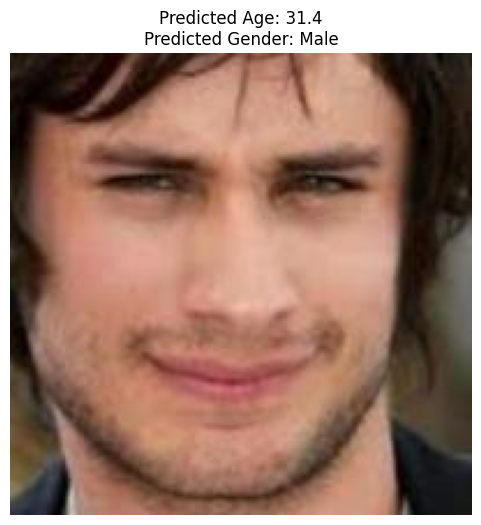

In [44]:
# Display the image with prediction

img = load_img(input_image)

plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.axis("off")

plt.title(
    f"Predicted Age: {predicted_age:.1f}\n"
    f"Predicted Gender: {predicted_gender}"
)

plt.show()